# Task 1

Implementation of binary classification datasets - from the datasets provided by the paper
* circle, crown or annulus
* squares/checkerboard-like data
* Wavy or non-convex boundaries
  
Include training/test splits; visualization function and label encoding

Libraries required

matplotlib for plots
numpy, os, scipy
scikit-learn

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

* gerador dos dados (usar a mesma função do artigo)
* visualizar
* analise estatistica do dataset
* divisão treino/teste


## Circle

In [31]:
#Generation function (article)

def circle(samples, random_seed=42):
    np.random.seed(random_seed)
    centers = np.array([[0, 0]])
    radii = np.array([np.sqrt(2/np.pi)]) #def radius so it represents 0.5 the area of the square - should be a balanced dataset in classification
    data=[]
    dim = 2
    for i in range(samples):
        x = 2 * (np.random.rand(dim)) - 1 #so that every point its inside the squared limit (-1,1)
        #random.rand = create an array of the given shape and populate it with random samples from a uniform distribution over [0, 1)
        y = 0
        for c, r in zip(centers, radii):  
            if np.linalg.norm(x - c) < r: #calculates distance between point and center to classify if inside the circle or not
                y = 1 

        data.append([x, y])
            
    return data, (centers, radii) 

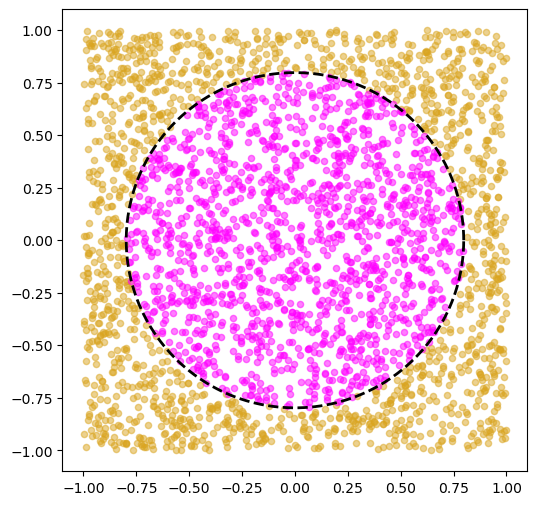

In [26]:
# Visualization funtion

def plot_circle(data, centers, radii):
    
    x = np.array([i[0] for i in data])
    y = np.array([i[1] for i in data])
    
    center = centers[0]
    radius = radii[0]
    
#Dataset with borders
    plt.figure(figsize=(6,6))
    plt.scatter(x[y == 0, 0], x[y == 0, 1], c='goldenrod', alpha=0.5, s=20, label='Outside')
    plt.scatter(x[y == 1, 0], x[y == 1, 1], c='fuchsia', alpha=0.5, s=20, label='Inside')
    
#Plotting the circle
    theta = np.linspace(0, 2*np.pi, 200)
    plt.plot(center[0] + radius * np.cos(theta), center[1] + radius * np.sin(theta), 
            'k--', linewidth=2, label='Border')
    
##Plotting square
#    square = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor='gray', linestyle=':')
#    plt.add_patch(square)
#    
#    plt.set_xlim(-1.2, 1.2)
#    plt.set_ylim(-1.2, 1.2)
#    plt.set_aspect('equal')
#    plt.grid(True, alpha=0.3)
#    plt.legend()
#    plt.set_xlabel('$x_0$')
#    plt.set_ylabel('$x_1$')
#    plt.set_title('Circle classification')
    
#Distance distribuition
#    ax = axes[1]
#    distances = np.linalg.norm(x - center, axis=1)
#    ax.hist(distances[y == 0], bins=30, alpha=0.6, label='Outside', color='goldenrod')
#    ax.hist(distances[y == 1], bins=30, alpha=0.6, label='Inside', color='fuchsia')
#    ax.axvline(radius, color='k', linestyle='--', linewidth=2, label='Radius')
#    
#    ax.set_xlabel('Distance from the center')
#    ax.set_ylabel('Frequence')
#    ax.set_title('Distance distribuition')
#    ax.legend()
#    ax.grid(True, alpha=0.3)
#    
#    plt.tight_layout()
#    return fig
#

#def analyze_circle(data, centers, radii):
#    
#    y = np.array([i[1] for i in data])
#    
#    n_inside = np.sum(y == 1)
#    n_outside = np.sum(y == 0)
#    
#    print("=" * 50)
#    print("Statistical Analysis")
#    print("=" * 50)
#    print(f"Total: {len(y)} samples")
#    print(f"Inside the circle:  {n_inside} ({100*n_inside/len(y):.1f}%)")
#    print(f"Outside the circle:    {n_outside} ({100*n_outside/len(y):.1f}%)")
#    print(f"Radius: {radii[0]:.6f}")
#    print(f"Center: {centers[0]}")
#    print("=" * 50)

data, (centers, radii) = circle(samples=3000, random_seed=42)

#analyze_circle(data, centers, radii)
fig = plot_circle(data, centers, radii)
plt.show()

In [10]:
#Train/test split
data, (centers, radii) = circle(samples=3000, random_seed=42)
x = np.array([i[0] for i in data])
y = np.array([i[1] for i in data])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)


print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Train: {len(x_test)} samples")
      

Train/Test datasets
Train: 2400 samples
Train: 600 samples


# Cherckerboard (Diamonds shape)

In [69]:
#Generation function
def checkerboard(samples, limit, scale, random_seed=42):
    np.random.seed(random_seed)
    
    #Coordinates
    x = np.random.uniform(0, limit, samples)
    y = np.random.uniform(0, limit, samples)
    
    #Default function: (floor((x+y)/s) + floor((x-y+s/2)/s)) mod 2
    logic = (np.floor((x + y) / scale).astype(int) + 
             np.floor((x - y + scale/2) / scale).astype(int)) % 2
    
    return x, y, logic

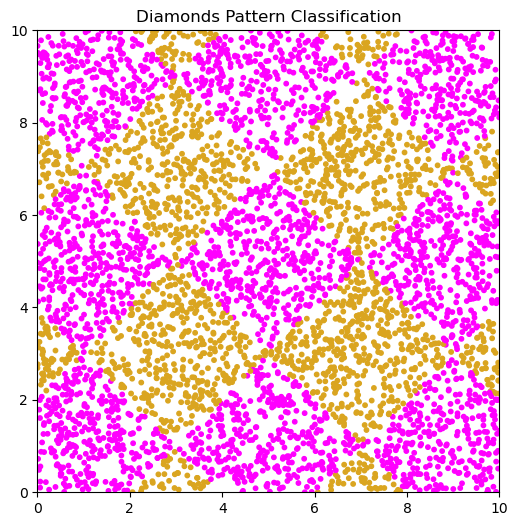

In [73]:
def plot_diamond(x_data, y_data, logic):
    colors = np.where(logic == 0, 'fuchsia', 'goldenrod')

    plt.figure(figsize=(6, 6))
    plt.scatter(x_data, y_data, c=colors, s=10)

    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.gca().set_aspect('equal')
    plt.title("Diamonds Pattern Classification")
    
x_data, y_data, logic = checkerboard(samples=5000, limit=10, scale=4.0)
fig = plot_diamond(x_data, y_data, logic)
plt.show()

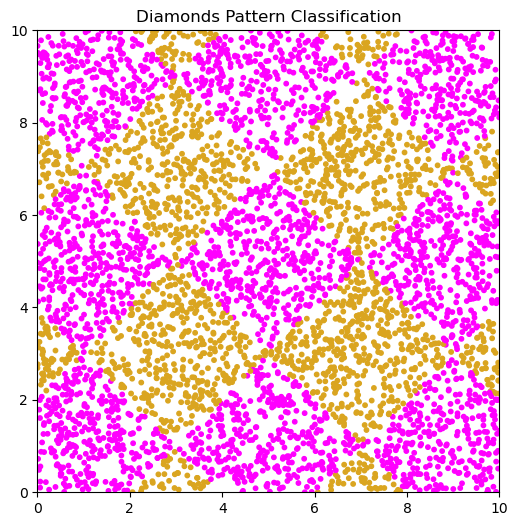

In [17]:
#Visualization function
x_data, y_data, pattern_labels = checkerboard(samples=5000, limit=10, scale=4.0)

#Mapping labels
colors = np.where(pattern_labels == 0, 'fuchsia', 'goldenrod')

plt.figure(figsize=(6, 6))
plt.scatter(x_data, y_data, c=colors, s=10)

plt.xlim(0, 10)
plt.ylim(0, 10)
plt.gca().set_aspect('equal')
plt.title("Diamonds Pattern Classification")
plt.show()


In [21]:
#Train/test split
x_data, y_data, pattern_labels = checkerboard(samples=5000, limit=10, scale=4.0)

x = np.column_stack((x_data, y_data))
y = pattern_labels


x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)


print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Train: {len(x_test)} samples")

Train/Test datasets
Train: 4000 samples
Train: 1000 samples


# Wavy

In [37]:
#Generation function (article)
def wavy_lines(samples, freq = 1):
    def fun1(s):
        return s + np.sin(freq * np.pi * s) #x+sin(πx)
    
    def fun2(s):
        return -s + np.sin(freq * np.pi * s) #−x+sin(πx)
    data=[]
    dim=2
    for i in range(samples): #labels atribuition
        x = 2 * (np.random.rand(dim)) - 1
        if x[1] < fun1(x[0]) and x[1] < fun2(x[0]): y = 0
        if x[1] < fun1(x[0]) and x[1] > fun2(x[0]): y = 1
        if x[1] > fun1(x[0]) and x[1] < fun2(x[0]): y = 2
        if x[1] > fun1(x[0]) and x[1] > fun2(x[0]): y = 3        
        data.append([x, y])

    return data, freq

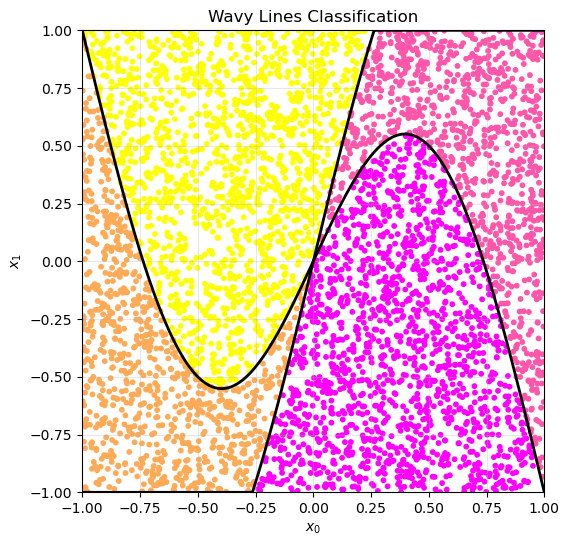

In [77]:
#Visualization Function
data, freq = wavy_lines(samples=5000, freq=1)

#separating into features and labels
x = np.array([i[0] for i in data]) 
y = np.array([i[1] for i in data])

plt.figure(figsize=(6,6))

plt.scatter(x[:,0], x[:,1], c=y, cmap='spring', s=10)
#plt.scatter(x[y == 0, 0], x[y == 0, 1], s=10, alpha=0.6, label='Class 0')
#plt.scatter(x[y == 1, 0], x[y == 1, 1], s=10, alpha=0.6, label='Class 1')
#plt.scatter(x[y == 2, 0], x[y == 2, 1], s=10, alpha=0.6, label='Class 2')
#plt.scatter(x[y == 3, 0], x[y == 3, 1], s=10, alpha=0.6, label='Class 3')

# curvas
s = np.linspace(-1, 1, 500)

plt.plot(
    s,
    np.clip(s + np.sin(freq * np.pi * s), -1, 1),
    'k-',
    linewidth=2
)

plt.plot(
    s,
    -s + np.sin(freq * np.pi * s),
    'k-',
    linewidth=2
)

# ajustes visuais
plt.xlim(-1,1)
plt.ylim(-1,1)

plt.gca().set_aspect('equal')
plt.grid(alpha=0.3)

plt.xlabel('$x_0$')
plt.ylabel('$x_1$')

plt.title('Wavy Lines Classification')

#plt.legend()

plt.show()

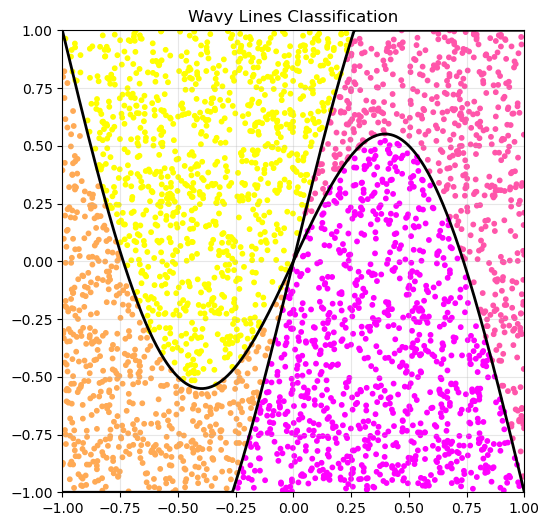

In [79]:
#Visualization Function

def plot_wavy(data,freq):
#separating into features and labels
    x = np.array([i[0] for i in data]) 
    y = np.array([i[1] for i in data])

    plt.figure(figsize=(6,6))

    plt.scatter(x[:,0], x[:,1], c=y, cmap='spring', s=10)

# curvas
    s = np.linspace(-1, 1, 500)
    plt.plot( s, np.clip(s + np.sin(freq * np.pi * s), -1, 1),   'k-', linewidth=2)
    plt.plot( s, -s + np.sin(freq * np.pi * s), 'k-', linewidth=2)
# ajustes visuais
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.gca().set_aspect('equal')
    plt.grid(alpha=0.3)
    plt.title('Wavy Lines Classification')
data, freq = wavy_lines(samples=3000, freq=1)
fig = plot_wavy(data,freq)
plt.show()

In [59]:

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [81]:

import sys
import warnings
warnings.filterwarnings('ignore') # Its for my shit macbook girls

#To find datasets
sys.path.append('../src') 
from datasets import get_iris_binary, plot_dataset

#Load and prepare the dataset (Setosa vs Versicolor)
X_train, X_test, y_train, y_test = get_iris_binary(task_type="setosa_vs_versicolor")

#Plot the 2D representation
plot_dataset(X_train, y_train)

SyntaxError: invalid syntax (datasets.py, line 137)